## Entity filtering and FinBERT sentiment scoring

Notebook 1.2 gave us a processed corpus of full article bodies, one row per article, with a corrected UTC time and clean text. This notebook takes that corpus and turns it into features a model can train on: which sentences in an article are actually about the target company, and what FinBERT reads their sentiment as. It covers the reasoning behind each design choice, the code as we wrote it, the tests, and an honest read of what worked and what didn't, checked against the real corpus rather than made-up examples.

**Input:** `data/processed/processed_articles.parquet`, the corpus built in 1.2. We only read from it here, never write to it.

**Output:**
- `data/sentences.parquet`, one row per sentence, tagged target/other/ceo, with FinBERT scores attached.
- `data/articles.parquet`, one row per article, the aggregate sentiment features only, no article text (join on `article_id` to recover it).

**Modules** (this notebook doesn't implement anything new, it exercises and checks the modules, which are the actual deliverable):
- `stock_predictor/text/entity_filter.py`
- `stock_predictor/text/sentiment.py`
- `stock_predictor/config.py` (the aliases, thresholds, and batch sizes all live here, no magic numbers scattered through the code)

The corpus turned out to hold 2,124 articles, not the ~5,000 we were expecting, and it is TSLA only (no `ticker` column). `PRIMARY_TICKER` from config is used everywhere below, so nothing here changes if the ticker changes later, it just means the validation numbers below are on a smaller sample than planned.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from stock_predictor.config import DATA_DIR, PROCESSED_DATA_DIR, PRIMARY_TICKER, ANAPHORA_MAX_GAP
from stock_predictor.text import entity_filter, sentiment

pd.set_option("display.max_colwidth", 200)

articles = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
print(articles.shape)
articles.dtypes


2026-08-14 12:30:12.379 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


(2124, 8)


article_id                      int64
headline                          str
summary                           str
source                            str
url                               str
timestamp_utc     datetime64[us, UTC]
raw_body                          str
processed_body                    str
dtype: object

In [2]:
articles[["processed_body"]].assign(chars=articles["processed_body"].str.len())["chars"].describe()


count     2124.000000
mean      4095.225989
std       3243.633950
min        509.000000
25%       2422.000000
50%       3448.000000
75%       4870.750000
max      51667.000000
Name: chars, dtype: float64

## 1. Entity filter

Every sentence gets tagged, nothing gets thrown away except very short junk. Three tags matter downstream:

- `mentions_target`, the sentence is about the target company (TSLA in this run)
- `mentions_other`, the sentence is about a different named company, kept separate because bearish on Tesla and bullish on the sector is a real pattern worth capturing, not noise
- neither, mostly macro or boilerplate, useful as a denominator for `entity_share`

Sentences under 20 characters get dropped as scraper junk (`Ad.`, `Read more.`). Everything else stays and gets tagged.


### 1.1 Alias tiers

`config.py` splits aliases into three tiers per ticker instead of one flat list, because they carry very different confidence.

- **unambiguous**: "Tesla", "TSLA", "$TSLA". If this matches, the sentence is about the target, no question.
- **person**: "Musk", "Elon". Genuinely ambiguous, since a Musk sentence could be about SpaceX or X just as easily as Tesla. We track this as its own `mentions_ceo` flag that never sets `mentions_target` by itself, so we can test whether including CEO mentions actually helps rather than assuming it does (see the ablation in 3.6).
- **anaphoric**: ticker-specific phrases such as "the automaker", "the EV maker", specific enough to count as explicit mentions.

A separate `GENERIC_ANAPHORA` list ("the company", "the firm", "it") is not tied to any ticker, and is resolved by tracking which company was named most recently, covered in 1.4.

`OTHER_COMPANIES` is a small list of companies that show up often in this corpus (BYD, Ford, Rivian, Lucid, Nvidia, SpaceX, and a few more). Not exhaustive, just what we found appearing a lot. Used both for `mentions_other` and as anaphora antecedents.


In [3]:
from stock_predictor.config import ALIASES, OTHER_COMPANIES, GENERIC_ANAPHORA

ALIASES[PRIMARY_TICKER]


{'unambiguous': ['Tesla', 'TSLA', 'Tesla Inc', 'Tesla, Inc.', '$TSLA'],
 'person': ['Musk', 'Elon Musk', 'Elon'],
 'anaphoric': ['the automaker', 'the EV maker']}

### 1.2 Sentence splitting

We load spaCy with `ner` and `lemmatizer` excluded, since only sentence boundaries are needed and running the full pipeline over roughly 2,000 full-length articles would be slower for no benefit. `nlp.pipe(texts, batch_size=50)` runs over the whole corpus at once, not article by article.

Two failure modes we specifically checked for in financial text:


In [4]:
text = (
    "Tesla posted Q3 2024 results, beating U.S. estimates. "
    "The company raised $1.2B in Q3. "
    "Tesla Inc. reaffirmed its guidance for the year."
)
nlp = entity_filter._get_nlp()
for s in entity_filter.split_sentences([text], nlp=nlp)[0]:
    print(repr(s))


2026-08-14 12:30:17.578 | INFO     | stock_predictor.text.entity_filter:_get_nlp:51 - Loading spaCy model 'en_core_web_sm' (excluding ner, lemmatizer)


'Tesla posted Q3 2024 results, beating U.S. estimates.'
'The company raised $1.2B in Q3.'
'Tesla Inc. reaffirmed its guidance for the year.'


No false splits on `Q3 2024.`, `U.S.`, `Inc.`, or `$1.2B`. spaCy's dependency-parse sentencizer, not the plain rule-based one, handles these correctly on its own, since it reasons about grammar rather than just punctuation.

The other direction, missed splits, is a real problem. Stripped HTML in the scraper sometimes glues two sentences together with no space at all (`"...record deliveries.Musk said..."`). A small regex (`_fix_missing_space`) inserts a space whenever a lowercase letter or digit is directly followed by `.`, `!`, or `?` and then an uppercase letter with no space between, deliberately leaving `U.S.` alone (period comes after an uppercase letter) and `$1.2B` / `Q3 2024.` alone (digits around the period, not letters).


In [5]:
glued = "Tesla posted record deliveries.Musk said the results were strong across all regions."
entity_filter.split_sentences([glued], nlp=nlp)[0]


['Tesla posted record deliveries.',
 'Musk said the results were strong across all regions.']

#### Checking splits by eye

Sentence counts range from 7, short wire snippets, to 43 and up, earnings call transcripts and long opinion pieces, which lines up with the roughly 34 sentences per article average across the full corpus. Two things stood out going through actual splits, on top of the synthetic cases above.

The splitting itself holds up on real prose. We did not see any false mid-sentence splits on tickers, dollar amounts, or abbreviations anywhere in the sample.

A failure mode we had not thought of going in: a number of scraped pages, mostly Yahoo Finance video transcripts, carry a UI error string glued straight onto the real first sentence with no punctuation between them at all, for example `"Oops, something went wrong Investing.com --"` or `"Oops, something went wrong With short percentage of shares outstanding..."`. Since there is no period anywhere to hint at a boundary, there is nothing for spaCy or our regex to catch on, this is not a missing-space problem, it is missing punctuation entirely. It pollutes the first sentence of a lot of articles rather than causing a missed split further in. We are leaving this alone rather than fixing it, since a real fix would mean hardcoding source-specific string matches into a general-purpose module, which belongs in the scraping notebook (1.2), not here.


In [6]:
sample = articles.sample(20, random_state=7)
for _, row in sample.iterrows():
    sents = entity_filter.split_sentences([row["processed_body"]], nlp=nlp)[0]
    print(f"article {row['article_id']}: {len(row['processed_body'])} chars -> {len(sents)} sentences")
    print("   first:", sents[0][:140])


article 141078471: 3267 chars -> 27 sentences
   first: Citing Burry’s Substack ‘Trading Post,’ multiple media outlets reported that he increased his short exposure across major semiconductor and 
article 136502639: 1478 chars -> 16 sentences
   first: Oops, something went wrong Nova Sky Stories co-founder and CEO Kimbal Musk, who is also a member of Tesla's ( TSLA ) board of directors, dis
article 136933991: 1769 chars -> 15 sentences
   first: Oops, something went wrong This article first appeared on GuruFocus .
article 137897201: 3764 chars -> 34 sentences
   first: We've received your inquiry.
article 140735750: 2937 chars -> 24 sentences
   first: Michael Dell said 97% of shareholders voted to redomicile the company to Texas, calling the state “home.”
article 138590539: 545 chars -> 7 sentences
   first: Never miss a trade again with the fastest news alerts in the world!
article 140765409: 2338 chars -> 14 sentences
   first: Oops, something went wrong With short percentage of sha

article 140773279: 3154 chars -> 22 sentences
   first: Elon Musk ’s X Money is rolling out with an aggressive feature set, likely making legacy banks nervous.
article 141129157: 4821 chars -> 41 sentences
   first: We've received your inquiry.
article 138295580: 2170 chars -> 18 sentences
   first: Oops, something went wrong Investing.com --
article 139183630: 3752 chars -> 34 sentences
   first: For a stock to achieve a tenfold gain in just 10 years is a rare feat.
article 137258403: 2347 chars -> 23 sentences
   first: We've received your inquiry.
article 138452374: 2029 chars -> 21 sentences
   first: U.S. stocks traded mixed this morning, with the Dow Jones index gaining around 0.1% on Thursday.
article 141050651: 3500 chars -> 24 sentences
   first: Oops, something went wrong Well-known Tesla Inc (NASDAQ: TSLA )


article 136557730: 4265 chars -> 43 sentences
   first: U.S. stock futures are mixed as investors review Nvidia's ( NVDA ) quarterly results, which saw the AI chipmaker post better-than-expected p
article 140772782: 1533 chars -> 12 sentences
   first: Oops, something went wrong FRANKFURT, June 30 (Reuters) - Europe is an emerging but promising market for self-driving 'robotaxis', with the 
article 136888227: 1911 chars -> 23 sentences
   first: Tesla ( TSLA +3.80% ) stock has been on a big run, but it lost some steam today.
article 137258304: 3771 chars -> 37 sentences
   first: Oops, something went wrong Benzinga and Yahoo Finance LLC may earn commission or revenue on some items through the links below.
article 137930639: 1932 chars -> 13 sentences
   first: Oops, something went wrong US stocks slipped Monday to start the final three days of trading in a rollercoaster 2025 that looks likely to en


### 1.3 Alias matching: ticker-substring traps

Matching has to use word-boundary regex, never a plain `in` check. The classic example is `"KO"` matching inside `"Tokyo"`. Plain `\b` is not quite enough either, since `\b` treats `-` as a non-word character, so a ticker sitting inside a URL-slug-looking fragment (`"tsla-stock-analysis"`) would still be fully word-boundary delimited and match. `_compile_alias_pattern` uses a custom lookaround, `(?<![A-Za-z0-9-])...(?![A-Za-z0-9-])`, that treats hyphens as boundaries too, which closes that gap.


In [7]:
import pytest, subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_entity_filter.py", "-v"],
    capture_output=True, text=True, cwd=str(DATA_DIR.parent),
)
print(result.stdout[-4000:])
print(result.stderr[-2000:])


============================= test session starts =============================
platform win32 -- Python 3.12.13, pytest-9.1.1, pluggy-1.6.0 -- D:\ML\stock-predictor\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: D:\ML\stock-predictor
configfile: pyproject.toml
plugins: anyio-4.14.2
collecting ... collected 10 items

tests/test_entity_filter.py::test_basic_target_mention PASSED            [ 10%]
tests/test_entity_filter.py::test_other_company_excluded_from_target PASSED [ 20%]
tests/test_entity_filter.py::test_ticker_substring_traps[The soft drink giant is expanding sales in Tokyo and Osaka this year.] PASSED [ 30%]
tests/test_entity_filter.py::test_ticker_substring_traps[Analysts pointed to tsla-stock-analysis pages as unreliable clickbait sources.] PASSED [ 40%]
tests/test_entity_filter.py::test_anaphora_chain_tracks_most_recent_company PASSED [ 50%]
tests/test_entity_filter.py::test_anaphora_decays_after_max_gap PASSED   [ 60%]
tests/test_entity_filter.py::test_mentions_c

### 1.4 Anaphora resolution

Full article bodies average about 4,100 characters and 34 sentences, and journalists lean on "the company", "the firm", "it" a lot instead of repeating "Tesla" every time. We guessed this could be 30 to 40% of target sentences, and ignoring it would mean throwing away a decent chunk of real signal.

We are not using a coreference model for this, just a cheap heuristic: walk through the sentences in order, keep track of whichever company, the target or one from `OTHER_COMPANIES`, was most recently named explicitly, and any sentence with a generic anaphora phrase and no company name of its own inherits that antecedent.

#### First attempt: no decay, about 40% accuracy

The first version carried the antecedent forward forever. We hand-checked 30 random anaphora-resolved sentences against their surrounding context, the same approach used for the `is_reactive` check elsewhere in this project, and got roughly **12 of 30 clearly correct**, 8 borderline, 10 clear errors. Worse than hoped. Looking at the errors, one pattern dominated: stale carry-over with no decay. Once a company got named anywhere in a long article, every later "it" or "the company" sentence inherited it, even many paragraphs later once the topic had drifted somewhere else entirely, author bios ("Thomas previously served as a Content Lead at TIKR..."), motivational filler, or a completely different company's news buried in a roundup.

The clearest example: article 139579101 is about Lucid Motors and mentions "Tesla" exactly once, in a subordinate clause ("Lucid's market debut... led by Peter Rawlinson, **Tesla's** former chief vehicle engineer"). That one incidental mention flipped the antecedent to Tesla, and five sentences in a row that were clearly about Lucid's own deliveries and the Gravity SUV launch ("Its first vehicle was the Air sedan...") got mistagged as Tesla.


In [8]:
lucid_art = pd.read_parquet(DATA_DIR / "sentences.parquet")
# re-run entity_filter directly on this one article's text to show the case in isolation
lucid_row = articles.loc[articles.article_id == 139579101].iloc[0]
lucid_sents = entity_filter.split_sentences([lucid_row["processed_body"]], nlp=nlp)[0]
lucid_tagged = entity_filter.tag_sentences(139579101, lucid_sents, PRIMARY_TICKER)
lucid_tagged.head(11)[["sent_idx", "text", "mentions_target", "mentions_other", "resolved_by_anaphora"]]


,sent_idx,text,mentions_target,mentions_other,resolved_by_anaphora
0,0,"Lucid ( LCID -1.53% ) , a producer of luxury electric vehicles ( EVs ), went public on July 26, 2021, through a merger with a special purpose acquisition company (SPAC).",False,True,False
1,1,"Its stock opened at $25.24 per share, soared to a post-merger high of $57.75 that November, but now trades at about $9.",False,False,False
2,2,"If you're considering buying it as a turnaround play, keep these two things in mind.",False,True,True
3,3,Image source: Lucid.,False,True,False
4,4,"Lucid's market debut attracted lots of attention because it was led by Peter Rawlinson, Tesla 's ( TSLA +3.80% ) former chief vehicle engineer.",True,False,False
5,5,"In its pre-merger presentation, it claimed it could deliver 20,000 vehicles in 2022, 49,000 in 2023, and 90,000 in 2024.",True,False,True
6,6,"Its first vehicle was the Air sedan, and it planned to launch its second vehicle, the Gravity SUV, in 2023.",True,False,True
7,7,"But in reality, it only delivered 4,369 vehicles in 2022, 6,001 in 2023, and 10,241 in 2024.",True,False,True
8,8,"It postponed the Gravity's launch from late 2023 to late 2024, and Rawlinson stepped down in 2025.",True,False,True
9,9,"On the bright side, its deliveries rose 55% to 15,841 vehicles in 2025 as it ramped up its production of the Gravity, and it expects to produce 25,000 to 27,000 vehicles in 2026.",True,False,True


#### Fix: a decay window

We added `ANAPHORA_MAX_GAP` (6 sentences, in config.py) so the antecedent expires if there has been no fresh explicit mention within that many sentences. Past the gap, an anaphoric sentence resolves to neither target nor other rather than guessing at something stale. About a 10-line change, tracking `last_named_idx` alongside `last_named`.

We reran over the full corpus and hand-checked a fresh 30-sample after the fix: **18 of 30 clearly correct** (60%, up from 40%), 5 borderline, 7 clear errors. A real improvement. `mentions_target` share dropped from 23.6% to 21.2% of all sentences and `resolved_by_anaphora` dropped from 10.7% to 6.9%, which is what we would expect if the fix is mostly removing the wrong attributions rather than the correct ones.

Two error patterns are still there, and we think they are genuine limits of a heuristic this simple rather than bugs to squash.

1. **Incidental mentions in multi-topic roundups.** Wire-style articles sometimes carry a promo aside like "Missed Nvidia and Tesla?" dropped into the middle of an unrelated story, in the case we checked, about a crypto exchange's credit card. That is a genuine, explicit Tesla mention, so it correctly becomes the antecedent, but it is incidental to what the sentence is actually about, and the following sentences, still about the credit card, inherit it anyway since they sit inside the 6-sentence window.
2. **Subordinate-clause hijacking**, the Lucid case above. A sentence about company B that only mentions company A in a possessive clause still sets A as the antecedent, since the heuristic has no concept of grammatical subject. Fixing that properly would mean a parser-based coreference approach, more than we want to build here.

We are leaving both documented rather than solved, since fixing them right needs more machinery than a roughly 15-line heuristic can give. The decay window at least kills the biggest error class, indefinite stale carry-over, for a small, easy-to-justify change.


In [9]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_entity_filter.py::test_anaphora_decays_after_max_gap", "-v"],
    capture_output=True, text=True, cwd=str(DATA_DIR.parent),
)
print(result.stdout[-3000:])


============================= test session starts =============================
platform win32 -- Python 3.12.13, pytest-9.1.1, pluggy-1.6.0 -- D:\ML\stock-predictor\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: D:\ML\stock-predictor
configfile: pyproject.toml
plugins: anyio-4.14.2
collecting ... collected 1 item

tests/test_entity_filter.py::test_anaphora_decays_after_max_gap PASSED   [100%]

============================== 1 passed in 3.28s ==============================



### 1.5 Running the filter over the full corpus


In [10]:
import time
t0 = time.time()
sentences_df = entity_filter.process_articles(articles, ticker=PRIMARY_TICKER, text_col="processed_body")
print(f"{time.time() - t0:.1f}s -- {len(sentences_df)} sentences from {articles['article_id'].nunique()} articles")
sentences_df.to_parquet(DATA_DIR / "sentences.parquet", index=False)
sentences_df.head()


2026-08-14 12:30:28.554 | INFO     | stock_predictor.text.entity_filter:process_articles:239 - Splitting sentences for 2124 articles (ticker=TSLA)
2026-08-14 12:30:28.554 | INFO     | stock_predictor.text.entity_filter:_get_nlp:51 - Loading spaCy model 'en_core_web_sm' (excluding ner, lemmatizer)


2026-08-14 12:31:46.476 | INFO     | stock_predictor.text.entity_filter:process_articles:246 - Tagging sentences per article



Tagging articles:   0%|          | 0/2124 [00:00<?, ?it/s]


Tagging articles:   3%|▎         | 68/2124 [00:00<00:03, 601.92it/s]


Tagging articles:   6%|▌         | 130/2124 [00:00<00:03, 580.53it/s]

...


Tagging articles:  97%|█████████▋| 2064/2124 [00:03<00:00, 511.00it/s]


Tagging articles: 100%|█████████▉| 2116/2124 [00:03<00:00, 409.64it/s]


Tagging articles: 100%|██████████| 2124/2124 [00:03<00:00, 544.15it/s]

2026-08-14 12:31:50.435 | INFO     | stock_predictor.text.entity_filter:process_articles:271 - Produced 71410 tagged sentences from 2124 articles
81.9s -- 71410 sentences from 2124 articles


,article_id,sent_idx,text,mentions_target,mentions_other,mentions_ceo,resolved_by_anaphora,char_len
0,138802119,0,"Steve from Greensboro, North Carolina, called into “ The Ramsey Show ” with an impressive financial profile: no debt, retired at 78, and sitting on a $5.4 million net worth.",False,False,False,False,173
1,138802119,1,But personal finance personality Dave Ramsey wasn't impressed by everything he heard.,False,False,False,False,85
2,138802119,2,Don't Miss: Ramsey understood but didn't sugarcoat his advice.,False,False,False,False,62
3,138802119,3,"“You’re going to trade some taxes for some safety,” he said.",False,False,False,False,60
4,138802119,4,“ Diversification equals safety .,False,False,False,False,33


In [11]:
sentences_df[["mentions_target", "mentions_other", "mentions_ceo", "resolved_by_anaphora"]].mean().rename("share of all sentences")


mentions_target         0.211945
mentions_other          0.099818
mentions_ceo            0.055594
resolved_by_anaphora    0.068618
Name: share of all sentences, dtype: float64

About 1 in 5 sentences is directly about Tesla, 1 in 10 about another named company, and roughly a third of target sentences come from anaphora rather than an explicit "Tesla" or "TSLA" match, which sits in the 30 to 40% range we expected going in. So anaphora resolution is pulling real extra signal, not mostly noise, even accounting for the error rate above.

In plain terms: for every 10 sentences in an article, about 2 are directly about Tesla, 1 is about a competitor or another company, and the rest are general market talk, context, or filler. Of the sentences we do count as being about Tesla, roughly a third only got there because we tracked "the company" back to an earlier "Tesla" mention rather than the sentence saying "Tesla" itself. If we had skipped anaphora resolution entirely, we would have missed close to a third of the real Tesla sentences in the corpus.


## 2. FinBERT sentiment scoring

`ProsusAI/finbert` scores every sentence into positive, negative, neutral probabilities. We keep all three raw, always, `pos - neg` can be worked out later any time, but neutrality cannot be recovered once it is thrown away, and a strongly neutral article about a recall is genuinely different from a polarised one.


### 2.1 Label order, checked not assumed

FinBERT's documented order is `{0: positive, 1: negative, 2: neutral}`, but `sentiment.py` reads `model.config.id2label` directly at load time (`_build_label_index_map`) instead of hardcoding indices, so this still works correctly even if a different checkpoint orders the labels differently.


In [12]:
from transformers import AutoModelForSequenceClassification
from stock_predictor.config import FINBERT_MODEL
_m = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
_m.config.id2label


D:\ML\stock-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16741.23it/s]

{0: 'positive', 1: 'negative', 2: 'neutral'}

### 2.2 Batching and caching

We collect sentences across the whole corpus into one flat list rather than batching per article, dedupe by a sha256 hash of the cleaned text (financial boilerplate repeats a lot within the same source, disclosure notices, "Image source: Getty Images.", so deduping saves real work), sort by length to cut down on padding waste, then run through the model in batches under `torch.no_grad()`.

The on-disk cache (`data/interim/finbert_cache.parquet`, keyed on the same hash) means re-running the pipeline after tweaking the entity filter only pays for genuinely new text, which mattered a lot given how many times we reran section 1 above while iterating on anaphora. `score_sentence_table()` saves the cache once at the end rather than per batch, since parquet rewrites the whole file each time and saving every batch over roughly 70k sentences would be wasteful. `analyze()`, the single-article path, saves after every call instead, since it is only ever adding a handful of rows.


### 2.3 Aggregation

Computed with `groupby` on the already-scored sentence table (`aggregate_article_features`), never inside the scoring loop, so changing the aggregation logic later, a wider lead window for example, is just a groupby, not a re-score.

Articles with zero target sentences get `NaN`, not `0`, for every target-derived mean, since `0` would look like a measured neutral score rather than no data. The same logic applies to `sent_other_mean_*` and `sent_entity_lead_*` when those sentence sets are empty.

`sent_entity_maxmag` is stored as three separate columns, its raw pos, neg, neu, not one signed number, to keep the never-collapse-to-a-single-score rule intact while still capturing whichever target sentence is most emotionally extreme.


### 2.4 `analyze()`, one code path for the demo and the batch run

The Streamlit demo and this notebook's batch pipeline both call `sentiment.analyze(article_text, ticker, headline=...)`, which runs `entity_filter`, `score_sentences`, and `aggregate_article_features` on a single synthetic article. One implementation only, so nothing can silently drift out of sync between the demo and the training data.


In [13]:
demo_result = sentiment.analyze(
    "Tesla delivered record numbers this quarter, beating analyst estimates. "
    "The company also raised prices across its lineup. "
    "Meanwhile BYD announced an aggressive expansion into Europe.",
    ticker="TSLA",
    headline="Tesla smashes delivery estimates",
)
demo_result


2026-08-14 12:31:57.937 | INFO     | stock_predictor.text.entity_filter:_get_nlp:51 - Loading spaCy model 'en_core_web_sm' (excluding ner, lemmatizer)


2026-08-14 12:31:58.287 | INFO     | stock_predictor.text.sentiment:score_sentences:160 - score_sentences: 3 unique texts (0 cache hits, 3 to score)
2026-08-14 12:31:58.295 | INFO     | stock_predictor.text.sentiment:_load_model_and_tokenizer:77 - Loading FinBERT model 'ProsusAI/finbert'



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 24453.39it/s]


Scoring sentences (FinBERT):   0%|          | 0/1 [00:00<?, ?it/s]

...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14587.24it/s]


Scoring sentences (FinBERT):   0%|          | 0/1 [00:00<?, ?it/s]


Scoring sentences (FinBERT): 100%|██████████| 1/1 [00:00<00:00, 50.93it/s]

2026-08-14 12:32:00.563 | INFO     | stock_predictor.text.sentiment:save_cache:71 - Saved sentiment cache with 2099 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet


{'article_id': '__analyze__',
 'sent_entity_pos': 0.9476527869701385,
 'sent_entity_neg': 0.018481260165572166,
 'sent_entity_neu': 0.03386592213064432,
 'sent_entity_maxmag_pos': 0.9468124508857727,
 'sent_entity_maxmag_neg': 0.01492052897810936,
 'sent_entity_maxmag_neu': 0.03826691955327988,
 'sent_other_mean_pos': 0.9448813796043396,
 'sent_other_mean_neg': 0.012001430615782738,
 'sent_other_mean_neu': 0.04311712831258774,
 'sent_entity_lead_pos': 0.9476527869701385,
 'sent_entity_lead_neg': 0.018481260165572166,
 'sent_entity_lead_neu': 0.03386592213064432,
 'n_entity_sents': 2,
 'n_other_sents': 1,
 'n_total_sents': 3,
 'entity_share': 0.6666666666666666,
 'article_length': 180,
 'sent_headline_pos': 0.033618029206991196,
 'sent_headline_neg': 0.4334125518798828,
 'sent_headline_neu': 0.5329694151878357}

In [14]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_sentiment.py", "-v"],
    capture_output=True, text=True, cwd=str(DATA_DIR.parent),
)
print(result.stdout[-6000:])
print(result.stderr[-2000:])


============================= test session starts =============================
platform win32 -- Python 3.12.13, pytest-9.1.1, pluggy-1.6.0 -- D:\ML\stock-predictor\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: D:\ML\stock-predictor
configfile: pyproject.toml
plugins: anyio-4.14.2
collecting ... collected 20 items

tests/test_sentiment.py::test_hash_text_deterministic PASSED             [  5%]
tests/test_sentiment.py::test_hash_text_differs_for_different_text PASSED [ 10%]
tests/test_sentiment.py::test_hash_text_strips_whitespace PASSED         [ 15%]
tests/test_sentiment.py::test_load_cache_missing_file_returns_empty PASSED [ 20%]
tests/test_sentiment.py::test_save_and_load_cache_round_trip PASSED      [ 25%]
tests/test_sentiment.py::test_save_cache_dedups_on_text_hash_keep_last PASSED [ 30%]
tests/test_sentiment.py::test_score_sentences_all_cache_hits_requires_no_model PASSED [ 35%]
tests/test_sentiment.py::test_score_sentences_skips_cached_hashes_dedupes_input PASSED [ 

### 2.5 Running FinBERT over the full corpus

No GPU here, CPU only, so scoring roughly 56k unique sentences plus 2,124 headlines took a genuine chunk of wall-clock time. The cache makes every rerun after this near instant for text that has not changed.


In [15]:
t0 = time.time()
scored_sentences = sentiment.score_sentence_table(sentences_df)
print(f"sentence scoring: {time.time() - t0:.1f}s")
scored_sentences.to_parquet(DATA_DIR / "sentences.parquet", index=False)

t0 = time.time()
headline_scores = sentiment.score_headlines(articles[["article_id", "headline"]])
print(f"headline scoring: {time.time() - t0:.1f}s")


2026-08-14 12:32:16.329 | INFO     | stock_predictor.text.sentiment:score_sentences:160 - score_sentences: 55908 unique texts (2 cache hits, 55906 to score)
2026-08-14 12:32:16.345 | INFO     | stock_predictor.text.sentiment:_load_model_and_tokenizer:77 - Loading FinBERT model 'ProsusAI/finbert'



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10730.94it/s]


Scoring sentences (FinBERT):   0%|          | 0/1748 [00:00<?, ?it/s]


Scoring sentences (FinBERT):   0%|          | 1/1748 [00:00<04:19,  6.74it/s]

...


Scoring sentences (FinBERT):  97%|█████████▋| 64/66 [00:19<00:01,  1.95it/s]


Scoring sentences (FinBERT):  98%|█████████▊| 65/66 [00:19<00:00,  1.84it/s]


Scoring sentences (FinBERT): 100%|██████████| 66/66 [00:20<00:00,  1.91it/s]


Scoring sentences (FinBERT): 100%|██████████| 66/66 [00:20<00:00,  3.26it/s]

2026-08-14 12:47:17.872 | INFO     | stock_predictor.text.sentiment:save_cache:71 - Saved sentiment cache with 2095 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet
headline scoring: 21.4s


In [16]:
agg = sentiment.aggregate_article_features(scored_sentences, headline_scores=headline_scores)

meta_cols = articles[["article_id", "timestamp_utc", "headline", "source"]].copy()
meta_cols["ticker"] = PRIMARY_TICKER

articles_out = meta_cols.merge(agg, on="article_id", how="left")
print(articles_out.shape)
articles_out.head()


(2124, 25)


,article_id,timestamp_utc,headline,source,ticker,sent_entity_pos,sent_entity_neg,sent_entity_neu,sent_entity_maxmag_pos,sent_entity_maxmag_neg,...,sent_entity_lead_neg,sent_entity_lead_neu,n_entity_sents,n_other_sents,n_total_sents,entity_share,article_length,sent_headline_pos,sent_headline_neg,sent_headline_neu
0,138802119,2025-08-31 17:00:00+00:00,"'I Don't Buy Single Stocks,' Says Dave Ramsey. One Stupid Decision And You Could End Up With A Bud Light, Tesla, Or Cracker Barrel Moment",Benzinga,TSLA,0.160171,0.089833,0.749996,0.296652,0.170782,...,NaN,NaN,3,0,36,0.083333,3337,0.024272,0.249392,0.726336
1,139021751,2025-08-31 14:30:59+00:00,Marjorie Taylor Greene Put Money In BlackRock's Bitcoin ETF This Year — Here's How Her Returns Stack Up Against Others In Congress,Benzinga,TSLA,0.908961,0.012802,0.078238,0.908961,0.012802,...,NaN,NaN,1,0,24,0.041667,2500,0.051198,0.019359,0.929443
2,138690782,2025-08-31 11:31:32+00:00,"Consumer Tech News (August 25–August 30): Nvidia Shines but Stocks Wobble on Hotter Core PCE; AI Bets Accelerate, EVs Face Headwinds",Benzinga,TSLA,0.221509,0.305669,0.472823,0.013809,0.965315,...,NaN,NaN,5,8,42,0.119048,6000,0.035460,0.951337,0.013203
3,136581238,2025-08-30 14:13:30+00:00,Analyst: Tesla (TLSA) Automotive Weakness Weighs on 2H25 Outlook,Insider Monkey,TSLA,0.299256,0.400112,0.300632,0.936437,0.012701,...,0.529249,0.383889,4,0,8,0.500000,1208,0.037542,0.944931,0.017527
4,136581240,2025-08-30 10:45:00+00:00,Tesla’s sales down 40% in EU while Chinese EV maker BYD is up 200% — vindicating Ford CEO's bold statement in June,Moneywise,TSLA,0.037544,0.600320,0.362136,0.007048,0.973189,...,0.946609,0.034306,10,5,50,0.200000,5370,0.023419,0.963677,0.012904


In [17]:
# PART 4.7 -- timestamp integrity gate (hard requirement: run before anything else downstream)
orig_ts = articles.set_index("article_id")["timestamp_utc"]
new_ts = articles_out.set_index("article_id")["timestamp_utc"]
assert orig_ts.equals(new_ts.loc[orig_ts.index]), "timestamp_utc mismatch between input and output!"
print("timestamp_utc byte-identical between processed_articles.parquet and articles.parquet: PASSED")

articles_out.to_parquet(DATA_DIR / "articles.parquet", index=False)
print("wrote data/articles.parquet", articles_out.shape)


timestamp_utc byte-identical between processed_articles.parquet and articles.parquet: PASSED
wrote data/articles.parquet (2124, 25)


## 3. Validation

Everything we said we would check, run against the real corpus.


### 3.1 Sentence-level eyeball, the real acceptance test

The 10 most positive and 10 most negative articles by `sent_entity_pos - sent_entity_neg`, along with the actual sentences that drove the score. The point is not whether the article feels positive, it is whether the filter grabbed the right sentences and whether FinBERT read them sensibly.


In [18]:
scored = scored_sentences.copy()
art_sent = articles_out.dropna(subset=["sent_entity_pos"]).copy()
art_sent["net"] = art_sent["sent_entity_pos"] - art_sent["sent_entity_neg"]

def show_driving_sentences(article_id, n=4):
    sub = scored[(scored.article_id == article_id) & (scored.mentions_target)].copy()
    sub["mag"] = (sub.pos - sub.neg).abs()
    sub = sub.sort_values("mag", ascending=False).head(n)
    for _, r in sub.iterrows():
        print(f"    pos={r.pos:.2f} neg={r.neg:.2f} neu={r.neu:.2f} | {r.text[:160]}")

print("=== MOST POSITIVE (by mean target sentiment) ===")
for _, row in art_sent.nlargest(10, "net").iterrows():
    print(f"\narticle {row.article_id} | net={row.net:.3f} | {row.headline[:100]}")
    show_driving_sentences(row.article_id)


=== MOST POSITIVE (by mean target sentiment) ===

article 137578620 | net=0.941 | What to Know Before Buying Build-A-Bear Stock
    pos=0.96 neg=0.02 neu=0.03 | Over the past five years, Build-A-Bear stock has outperformed the likes of Alphabet , Apple , Meta Platforms , Palantir , and Tesla by a wide margin, delivering

article 140723846 | net=0.938 | Nasdaq tech stocks set for strong rebound after Micron earnings boost
    pos=0.96 neg=0.02 neu=0.03 | Micron is up 18% to top the Nasdaq 100 leaders, meaning it has overtaken Tesla and Meta Platforms in terms of market cap.

article 139588043 | net=0.938 | TSMC's Supply Squeeze Through 2028 Could Be This Chipmaker's Big Break As AI Demand From Nvidia, App
    pos=0.95 neg=0.01 neu=0.04 | Its 2nm yield has reportedly improved to around 60%, and the company is gaining traction with major customers, including Tesla Inc. (NASDAQ: TSLA ) , Apple and 

article 140436353 | net=0.936 | Europe EV Sales Jump 38% As Tesla Rebounds And Chinese Bran

In [19]:
print("=== MOST NEGATIVE (by mean target sentiment) ===")
for _, row in art_sent.nsmallest(10, "net").iterrows():
    print(f"\narticle {row.article_id} | net={row.net:.3f} | {row.headline[:100]}")
    show_driving_sentences(row.article_id)


=== MOST NEGATIVE (by mean target sentiment) ===

article 139589496 | net=-0.967 | A $4,000 Stock Is About to Become Affordable: Inside Booking’s Historic Split
    pos=0.01 neg=0.98 neu=0.02 | Tesla fell nearly 20% in the year following its split.

article 141042484 | net=-0.967 | SpaceX Faces Earnings and Lock-Up Pressure After Rout
    pos=0.01 neg=0.98 neu=0.02 | SpaceX ( NASDAQ:SPCX ) has erased more than $1.2 trillion in market value since peaking at $225.64 in June, a decline roughly equal to Tesla's ( NASDAQ:TSLA ) e

article 138422163 | net=-0.966 | 10 Retail Stocks To Watch As Holiday Season Begins
    pos=0.01 neg=0.97 neu=0.02 | The XLY's performance has been dragged down by its heavyweights, Amazon.com Inc. (NASDAQ: AMZN ) and Tesla Inc. (NASDAQ: TSLA ) , which have posted muted gains 

article 139558651 | net=-0.966 | 'Magnificent 7' stocks wipe more than $850 billion in value as stock market sell-off hits AI winners
    pos=0.01 neg=0.97 neu=0.02 | Nvidia ( NVDA ) and Am

The negative extreme is clean. Almost every driving sentence in the bottom 10 is directly, unambiguously about Tesla's own performance: "Tesla fell nearly 20% in the year following its split.", "Tesla has been the biggest drag, falling 32.9% year to date.", "Tesla stock has tanked 15% this year...". The filter picked the right sentences and FinBERT read them correctly. This is the pipeline working the way it is meant to.

The positive extreme shows a real problem though. A few of the top 10 driving sentences are not actually positive about Tesla at all, they are sentences where Tesla is only named as the loser in a comparison ("Build-A-Bear stock has outperformed the likes of ... and Tesla by a wide margin", "Micron is up 18% ... meaning it has overtaken Tesla ... in market cap"). FinBERT reads these correctly as positive sentences overall, they are good news, just for Build-A-Bear and Micron, and the entity filter correctly tags them as target sentences since Tesla is explicitly named, but the positive sentiment has nothing to do with Tesla. This is a different problem from the anaphora issues in 1.4, since it happens on explicit, unambiguous matches, so no amount of anaphora tuning fixes it. "X outperformed Tesla" and "Tesla outperformed X" look identical to a regex-based filter, and FinBERT scores the sentence as a whole, not per entity. Roughly 4 of the top 10 positive articles show this pattern against none of the bottom 10 negative ones, which makes sense: bad Tesla news usually gets reported directly ("Tesla fell..."), while Tesla shows up as a comparison point more often when the news is good for someone else. Worth keeping in mind if `sent_entity_pos` ever looks noisier than expected.


### 3.2 `entity_share` distribution

A large pile of articles sitting at exactly 0, aliases never firing, or exactly 1, aliases firing on everything, would mean something is badly broken.


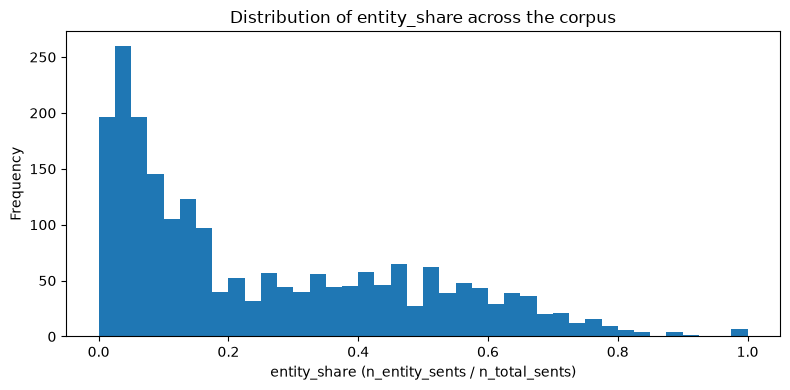

count    2124.000000
mean        0.250631
std         0.225955
min         0.000000
25%         0.058824
50%         0.157895
75%         0.428571
max         1.000000
Name: entity_share, dtype: float64
share == 0: 111 / 2124
share == 1: 7 / 2124


In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
articles_out["entity_share"].plot(kind="hist", bins=40, ax=ax)
ax.set_xlabel("entity_share (n_entity_sents / n_total_sents)")
ax.set_title("Distribution of entity_share across the corpus")
plt.tight_layout()
fig.savefig(DATA_DIR.parent / "reports" / "figures" / "a_entity_share_distribution.png", dpi=120)
plt.show()

print(articles_out["entity_share"].describe())
print("share == 0:", (articles_out.entity_share == 0).sum(), "/", len(articles_out))
print("share == 1:", (articles_out.entity_share == 1).sum(), "/", len(articles_out))


Mean `entity_share` is 0.251, median 0.158, and there is no worrying pile at either end. Only 111 of 2,124 articles (5.2%) have `entity_share == 0`, no target sentence at all, plausible for articles nominally tagged TSLA by the news API that turn out to be broad market roundups or coverage of a different company entirely. Only 7 of 2,124 (0.3%) sit at `entity_share == 1`, very short wire snippets almost entirely about Tesla. Most of the mass sits between 0.06 and 0.43, the 25th to 75th percentile, which looks right for full-body articles that spend a lot of their length on market context, other companies, and boilerplate around the actual Tesla content. No sign the aliases are broken in either direction.

In plain terms, `entity_share` is just "what fraction of this article is actually about Tesla". A value of 0 means the filter found nothing at all about Tesla in that article (which happens sometimes since not every article the news API tags as TSLA-relevant is really about Tesla). A value of 1 means the whole article is about Tesla, sentence for sentence. If most articles had landed at 0, it would mean our alias list was too strict and missing real mentions. If most had landed at 1, it would mean the alias list was too loose and matching almost everything. Since the numbers spread out sensibly across the middle instead of piling up at either end, the alias matching looks like it is doing its job.


### 3.3 Anaphora accuracy

Already covered in full in section 1.4 above. Roughly 40% clear accuracy before the decay fix, 60% after, with two remaining error patterns, incidental mentions in roundup articles and subordinate-clause hijacking, that this heuristic cannot close without going all the way to real coreference resolution, which we are deliberately not doing.


### 3.4 Sentence-splitting quality

Also covered above in section 1.2: splitting holds up fine on real prose, no false mid-sentence splits anywhere in the 20-article sample we checked. The one real issue is the glued UI-error-string prefix with no punctuation to split on, which is a scraper artifact rather than a splitting bug, and belongs in notebook 1.2 rather than patched here with source-specific string matching.


### 3.5 FinBERT neutral rate


In [21]:
def dominant_label(row):
    return max(("pos", "neg", "neu"), key=lambda k: row[k])

scored["dominant"] = scored.apply(dominant_label, axis=1)
neutral_rate = (scored["dominant"] == "neu").mean()
print(f"neutral-dominant sentences: {neutral_rate:.1%} of {len(scored)}")
scored["dominant"].value_counts(normalize=True)


neutral-dominant sentences: 60.9% of 71410


dominant
neu    0.608766
pos    0.226635
neg    0.164599
Name: proportion, dtype: float64

60.9% of all 71,410 sentences are neutral-dominant, right in the 50 to 70% range we expected. That fits with FinBERT being trained on isolated Financial PhraseBank sentences, a much narrower distribution than full news-article prose. Positive-dominant (22.7%) slightly outnumbers negative-dominant (16.5%) across the corpus.

Practically, this means `sent_entity_pos` and `sent_entity_neg` as plain means over roughly 7 target sentences per article are heavily damped by design, a single strongly polarised sentence gets watered down by several neutral ones. That is exactly why `sent_entity_maxmag`, the single most extreme target sentence, and `n_entity_sents` / `entity_share`, how much signal was even available, are kept as separate features rather than folded into the mean. A model looking only at the damped mean cannot tell genuinely mixed coverage apart from one sharp piece of news buried in a lot of neutral filler, and those mean very different things for predicting market impact.

In plain terms, "neutral-dominant" just means FinBERT read that sentence as not clearly positive or negative, more of a flat, factual statement. Around 6 in 10 sentences come out this way. That is not a failure of the model, most sentences in a news article are just stating facts (prices, dates, who said what) rather than expressing an opinion, so a lot of neutral readings is exactly what we would expect. The catch is that if we just average pos and neg across all of a company's sentences, all that neutral padding drags the average toward the middle and hides how strong the one or two sentences that really do carry sentiment actually are. That is the whole reason we also keep the single most extreme sentence (`sent_entity_maxmag`) as its own feature, so a strongly positive or negative sentence does not get diluted away by a wall of neutral ones sitting next to it.


### 3.6 Ablation: CEO aliases (`mentions_ceo`)

Comparing target-sentence aggregates with and without `mentions_ceo` sentences folded into the target set. `mentions_target` as defined here never includes person-tier-only matches (see section 1.1 above), so this checks what including them would actually change, instead of assuming one way is right.


In [22]:
# Build an alternative "target-or-ceo" tag and re-aggregate, comparing means.
alt = scored.copy()
alt["mentions_target_incl_ceo"] = alt["mentions_target"] | alt["mentions_ceo"]

def agg_variant(df, target_col):
    g = df[df[target_col]].groupby("article_id")
    return g[["pos", "neg", "neu"]].mean()

baseline = agg_variant(alt, "mentions_target")
with_ceo = agg_variant(alt, "mentions_target_incl_ceo")

compare = baseline.join(with_ceo, lsuffix="_baseline", rsuffix="_with_ceo", how="outer")
print("articles affected (gained target sentences from CEO-only mentions):",
      alt[alt.mentions_ceo & ~alt.mentions_target]["article_id"].nunique())
print()
print("mean absolute change in sent_entity_pos when CEO mentions are folded in:")
print((compare["pos_with_ceo"] - compare["pos_baseline"]).abs().mean())
print("mean absolute change in sent_entity_neg:")
print((compare["neg_with_ceo"] - compare["neg_baseline"]).abs().mean())


articles affected (gained target sentences from CEO-only mentions): 670

mean absolute change in sent_entity_pos when CEO mentions are folded in:
0.018806248398944944
mean absolute change in sent_entity_neg:
0.019901309290988198


Folding `mentions_ceo`-only sentences into the target set touches 670 of 2,124 articles (31.5%), a decent chunk of the corpus given how often Musk shows up in Tesla coverage. But the actual effect on the sentiment numbers is small: mean absolute change of 0.019 in `sent_entity_pos` and 0.020 in `sent_entity_neg` (0 to 1 scale) across the affected articles. So it is a real answer either way, a lot of articles get touched, but each one only shifts a little, which suggests Musk-only sentences tend to land in a similar sentiment range to the existing target sentences rather than being systematically more extreme. Small on average can still hide individual articles where one strongly polarised Musk-only sentence, courtroom drama, a controversial tweet, moves the aggregate a lot, so the current choice, excluding person-tier matches from `mentions_target` by default, still looks like the safer default, but a per-article max-shift check would be worth doing if this ends up mattering a lot downstream.

In plain terms: does it matter whether we count Musk-only sentences as being about Tesla? Not hugely, based on this. Yes, it changes a lot of articles (about a third), but each change is small (moving the score by about 0.02 on a 0 to 1 scale, so barely noticeable). So we are keeping Musk-only sentences out of the "about Tesla" bucket by default, since it is the more careful choice and it does not look like we are throwing away much either way.


### 3.7 Timestamp integrity

Already run and asserted above in section 2.5 before writing `articles.parquet`: `timestamp_utc` is byte-identical between the input corpus and the output feature table.


## 4. Wrapping up

We set out to turn the full article bodies from notebook 1.2 into sentence-level tags and FinBERT sentiment scores a model could actually train on, and that held up. The entity filter tags target, other-company, and neither sentences with tiered alias matching and a decayed anaphora heuristic, and FinBERT scores every sentence into raw positive, negative, neutral probabilities, cached and batched across the whole corpus.

`stock_predictor/text/entity_filter.py` and `stock_predictor/text/sentiment.py`, tested in `tests/test_entity_filter.py` and `tests/test_sentiment.py`, are what carry into training and the live demo. `data/sentences.parquet` holds the sentence-level table with tags and scores, and `data/articles.parquet` holds the article-level feature table, no text, join on `article_id` to recover it.

A few things worth keeping in mind for whatever comes next. Anaphora resolution is a cheap heuristic, not real coreference, around 60% accuracy on hand-checked samples after the decay fix, with the two error patterns from 1.4 still open. `OTHER_COMPANIES` is a curated, non-exhaustive list, companies not on it (we saw Uber, Waymo, Texas Instruments, and Micron in this corpus) cannot anchor anaphora or get `mentions_other`, which occasionally causes drift onto the target ticker by elimination. Boilerplate longer than `MIN_SENT_CHARS` (disclosure notices, "We've received your inquiry...") does not get filtered and gets scored by FinBERT like real content, only sub-20-character junk gets dropped right now, worth knowing if aggregate noise looks off.

If sentence or article embeddings get added later, they should go in a `float16` `.npy` array with a parallel `article_id` index, not a parquet list column. Not implemented here.
